# Data Preprocessing
## Inventory Restocking RL Project
**Author:** Pratheesha 
**Purpose:** Clean the dataset and prepare it for the RL environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Make sure project root is in path
sys.path.append('..')
import config

print("Libraries imported successfully!")
print(f"Raw data path  : {config.DATA_RAW_PATH}")
print(f"Processed path : {config.DATA_PROCESSED_PATH}")

Libraries imported successfully!
Raw data path  : D:\Y4S1\Machine Learning- IT4060\Project\inventory-restocking-project\data\raw\retail_inventory.csv
Processed path : D:\Y4S1\Machine Learning- IT4060\Project\inventory-restocking-project\data\processed\preprocessed_product.csv


## Load Raw Data

In [2]:
df = pd.read_csv(config.DATA_RAW_PATH)
print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded dataset: 73,100 rows × 15 columns


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Handle Missing Values

In [3]:
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

# Fill numerical columns with median
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Filled '{col}' nulls with median: {median_val:.2f}")

# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  Filled '{col}' nulls with mode: {mode_val}")

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

Missing values BEFORE cleaning:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Missing values AFTER cleaning:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


## Remove Duplicates

In [4]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after} duplicate rows.")
print(f"Remaining rows: {after:,}")

Removed 0 duplicate rows.
Remaining rows: 73,100


## Parse Dates and Extract Time Features

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day_of_Week'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("Date features added:")
print(df[['Date', 'Day_of_Week', 'Month', 'Year']].head(10))

Date features added:
        Date  Day_of_Week  Month  Year
0 2022-01-01            5      1  2022
1 2022-01-01            5      1  2022
2 2022-01-01            5      1  2022
3 2022-01-01            5      1  2022
4 2022-01-01            5      1  2022
5 2022-01-01            5      1  2022
6 2022-01-01            5      1  2022
7 2022-01-01            5      1  2022
8 2022-01-01            5      1  2022
9 2022-01-01            5      1  2022


## Select One Store-Product Pair for RL Environment

In [8]:
# Let's explicitly pick Store S001 and its most popular product
target_store = 'S001'
df_store = df[df['Store ID'] == target_store]

product_counts = df_store['Product ID'].value_counts()
selected_product = product_counts.index[0]

print(f"Selected Store ID   : {target_store}")
print(f"Selected Product ID : {selected_product}")
print(f"Records for pair    : {product_counts[selected_product]:,}")

# Filter for BOTH Store and Product
df_product = df[(df['Store ID'] == target_store) & (df['Product ID'] == selected_product)].copy()
df_product = df_product.sort_values('Date').reset_index(drop=True)

print(f"\nDate range: {df_product['Date'].min()} → {df_product['Date'].max()}")
df_product.head()

Selected Store ID   : S001
Selected Product ID : P0001
Records for pair    : 731

Date range: 2022-01-01 00:00:00 → 2024-01-01 00:00:00


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Day_of_Week,Month,Year
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,5,1,2022
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring,6,1,2022
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter,0,1,2022
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter,1,1,2022
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter,2,1,2022


## Create Promotion Flag

In [9]:
# Check if the old column name exists, and rename it if it does
if 'Holiday/Promotion' in df_product.columns:
    df_product = df_product.rename(columns={'Holiday/Promotion': 'Promo_Flag'})
    df_product['Promo_Flag'] = df_product['Promo_Flag'].astype(int)
    print("Successfully renamed 'Holiday/Promotion' to 'Promo_Flag'")
    
elif 'Promo_Flag' not in df_product.columns:
    # Fallback in case there is no promotion data at all
    df_product['Promo_Flag'] = 0
    print("Warning: 'Holiday/Promotion' column not found. Promo_Flag set to 0.")

print(f"Promo_Flag distribution:\n{df_product['Promo_Flag'].value_counts()}\n")

# Display the first 5 rows to verify the column name change
df_product.head()


Successfully renamed 'Holiday/Promotion' to 'Promo_Flag'
Promo_Flag distribution:
Promo_Flag
0    382
1    349
Name: count, dtype: int64



,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Promo_Flag,Competitor Pricing,Seasonality,Day_of_Week,Month,Year
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,5,1,2022
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring,6,1,2022
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter,0,1,2022
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter,1,1,2022
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter,2,1,2022


## Discretise Stock Level into Bins

Stock bin distribution:
Stock_Bin
High (2)      717
Medium (1)     14
Name: count, dtype: int64


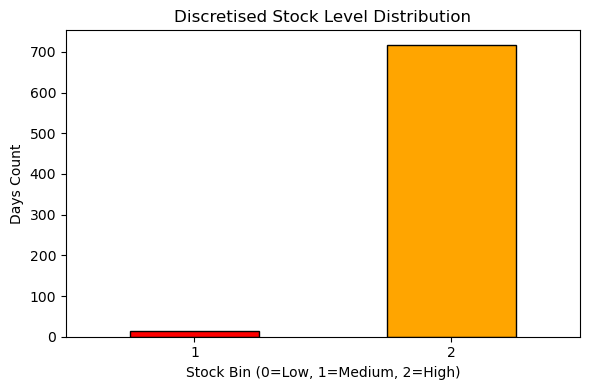

In [10]:
# Discretise stock into 3 bins using config thresholds
# Low=0 (< 20 units), Medium=1 (20-59 units), High=2 (60+ units)

def discretise_stock(stock):
    if stock < config.STOCK_LOW_THRESHOLD:
        return 0   # Low
    elif stock < config.STOCK_HIGH_THRESHOLD:
        return 1   # Medium
    else:
        return 2   # High

df_product['Stock_Bin'] = df_product['Inventory Level'].apply(discretise_stock)

print("Stock bin distribution:")
bin_labels = {0: 'Low (0)', 1: 'Medium (1)', 2: 'High (2)'}
print(df_product['Stock_Bin'].map(bin_labels).value_counts())

# Visualise
plt.figure(figsize=(6, 4))
df_product['Stock_Bin'].value_counts().sort_index().plot(
    kind='bar', color=['red', 'orange', 'green'], edgecolor='black'
)
plt.title('Discretised Stock Level Distribution')
plt.xlabel('Stock Bin (0=Low, 1=Medium, 2=High)')
plt.ylabel('Days Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/plots/preprocessing_stock_bins.png', dpi=150)
plt.show()

## Select Final Columns and Save

In [11]:
# Select only the columns needed by the RL environment
final_columns = [
    'Date', 'Day_of_Week', 'Month', 'Year',
    'Units Sold', 'Inventory Level', 'Stock_Bin', 'Promo_Flag'
]

# Keep only columns that exist in the dataframe
final_columns = [col for col in final_columns if col in df_product.columns]
df_final = df_product[final_columns].copy()

print(f"Final dataset shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")
df_final.head(20)

Final dataset shape: (731, 8)
Columns: ['Date', 'Day_of_Week', 'Month', 'Year', 'Units Sold', 'Inventory Level', 'Stock_Bin', 'Promo_Flag']


,Date,Day_of_Week,Month,Year,Units Sold,Inventory Level,Stock_Bin,Promo_Flag
0,2022-01-01,5,1,2022,127,231,2,0
1,2022-01-02,6,1,2022,81,116,2,0
2,2022-01-03,0,1,2022,5,154,2,0
3,2022-01-04,1,1,2022,58,85,2,1
4,2022-01-05,2,1,2022,147,238,2,1
5,2022-01-06,3,1,2022,37,198,2,0
6,2022-01-07,4,1,2022,107,195,2,1
7,2022-01-08,5,1,2022,2,231,2,1
8,2022-01-09,6,1,2022,350,373,2,1
9,2022-01-10,0,1,2022,36,327,2,1


In [12]:
# Save preprocessed data
os.makedirs(os.path.dirname(config.DATA_PROCESSED_PATH), exist_ok=True)
df_final.to_csv(config.DATA_PROCESSED_PATH, index=False)
print(f"Saved to: {config.DATA_PROCESSED_PATH}")
print(f"File size: {os.path.getsize(config.DATA_PROCESSED_PATH) / 1024:.1f} KB")

Saved to: D:\Y4S1\Machine Learning- IT4060\Project\inventory-restocking-project\data\processed\preprocessed_product.csv
File size: 23.4 KB


## Preprocessing Complete 
The preprocessed file is saved to `data/processed/preprocessed_product.csv`.  
Other Members can now use this file via `config.DATA_PROCESSED_PATH`.